# Model Testing Notebook

Imports

In [34]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, Sequential
from keras.utils import image_dataset_from_directory

# model building imports
from keras import Model, Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, RandAugment, GlobalAveragePooling2D, GlobalMaxPool2D
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score

#Model Class
from keras import Model

Import data sample and split

In [21]:
train_sample_df, val_sample_df = image_dataset_from_directory(
    "wikiart_sample",
    label_mode= "categorical",
    image_size=(512,512),
    seed=42,
    interpolation="bilinear",
    batch_size=64,
    validation_split = 0.2,
    subset="both"
)

Found 2656 files belonging to 23 classes.
Using 2125 files for training.
Using 531 files for validation.


Import all data and split

In [2]:
train_df, val_df = image_dataset_from_directory(
    "wikiart_datasets",
    label_mode= "categorical",
    image_size=(512,512),
    seed=42,
    interpolation="bilinear",
    batch_size=64,
    validation_split = 0.2,
    subset="both"
)

Found 13340 files belonging to 23 classes.
Using 10672 files for training.
Using 2668 files for validation.


In [3]:
input_shape= (512,512,3)

In [6]:
First_model = Sequential(
    layers= [Input(input_shape),
             Rescaling(scale= 1./255),

             #Primeira Convolutional
             Conv2D(filters=30, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),

            #Segunda Convolutional
             Conv2D(filters=60, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),

            #Terceira Convolutional
             Conv2D(filters=120, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),
              
            #Flatten e Dense layer
            Flatten(),

            #Primeiro Dense layer com mais neurons
            Dense(40, activation="relu"),

            #Second dense layer
            Dense(23, activation="softmax")
            
               ])


In [8]:
First_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 510, 510, 30)   │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 30)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 60)   │        16,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 60)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 120)  │        64,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 120)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 461280)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 40)             │    18,451,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │           943 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,534,203 (70.70 MB)

 Trainable params: 18,534,203 (70.70 MB)

 Non-trainable params: 0 (0.00 B)

Próxima parte temos de definar o que vai no Comlile, ou seja:

- A loss function
- O optimizer 
- As metrics

In [ ]:
optimizer = SGD(learning_rate=0.01, name="optimizer")
loss = CategoricalCrossentropy(name="loss")

In [ ]:
# metrics usadas para todos os modelos
categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [15]:
#Dar compile com o que acabamos de definir
First_model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [16]:
#Defenir número de epoches e batch size

epochs = 10
batchsize= 64

In [ ]:
#Dar fit do modelo de sample

First_model.fit(
    train_sample_df,
    validation_data=val_sample_df,
    epochs=epochs
)                            #Não é preciso meter batch_size porque já foi especificado quando importarmos os dados

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.0692 - auc: 0.5416 - f1_score: 0.0229 - loss: 3.1570 - val_accuracy: 0.0395 - val_auc: 0.5385 - val_f1_score: 0.0150 - val_loss: 3.1414
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.0795 - auc: 0.5751 - f1_score: 0.0288 - loss: 3.0977 - val_accuracy: 0.1036 - val_auc: 0.5871 - val_f1_score: 0.0256 - val_loss: 3.0853
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.1021 - auc: 0.5980 - f1_score: 0.0362 - loss: 3.0681 - val_accuracy: 0.0603 - val_auc: 0.5467 - val_f1_score: 0.0183 - val_loss: 3.3935
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.1172 - auc: 0.6211 - f1_score: 0.0318 - loss: 3.0340 - val_accuracy: 0.1168 - val_auc: 0.6152 - val_f1_score: 0.0325 - val_loss: 3.0541
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.1529 - auc: 0.6492 - f1_score: 0.0405 - loss: 2.9779 - val_accuracy: 0.0942 - val_auc: 0.6362 - val_f1_score: 0.0251 - val_loss: 3.032

Dar plot das metrics

In [20]:
print(First_model.history.keys()) 

AttributeError: 'History' object has no attribute 'keys'

In [28]:
def plot_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train')
    axes[0, 0].plot(history.history['val_loss'], label='Val')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()

    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Train')
    axes[0, 1].plot(history.history['val_accuracy'], label='Val')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()

    # F1 Score
    axes[1, 0].plot(history.history['f1_score'], label='Train')
    axes[1, 0].plot(history.history['val_f1_score'], label='Val')
    axes[1, 0].set_title('F1 Score')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].legend()

    # AUC
    axes[1, 1].plot(history.history['auc'], label='Train')
    axes[1, 1].plot(history.history['val_auc'], label='Val')
    axes[1, 1].set_title('AUC')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
plot_history(First_model)

Primeiro modelo com todos os dados

In [23]:
AD_first_model =First_model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)         

Epoch 1/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.2254 - auc: 0.7462 - f1_score: 0.1151 - loss: 2.7100 - val_accuracy: 0.2095 - val_auc: 0.7509 - val_f1_score: 0.1265 - val_loss: 2.7042
Epoch 2/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 483s 3s/step - accuracy: 0.2567 - auc: 0.7833 - f1_score: 0.1663 - loss: 2.5736 - val_accuracy: 0.2549 - val_auc: 0.7760 - val_f1_score: 0.1660 - val_loss: 2.6005
Epoch 3/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 481s 3s/step - accuracy: 0.2823 - auc: 0.8083 - f1_score: 0.2029 - loss: 2.4657 - val_accuracy: 0.2178 - val_auc: 0.7829 - val_f1_score: 0.1435 - val_loss: 2.6188
Epoch 4/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.3033 - auc: 0.8273 - f1_score: 0.2314 - loss: 2.3753 - val_accuracy: 0.2676 - val_auc: 0.8070 - val_f1_score: 0.1998 - val_loss: 2.4915
Epoch 5/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.3343 - auc: 0.8433 - f1_score: 0.2688 - loss: 2.2821 - val_accuracy: 0.2702 - val_auc: 0.7997 - val_f1_score: 0.2084 - va

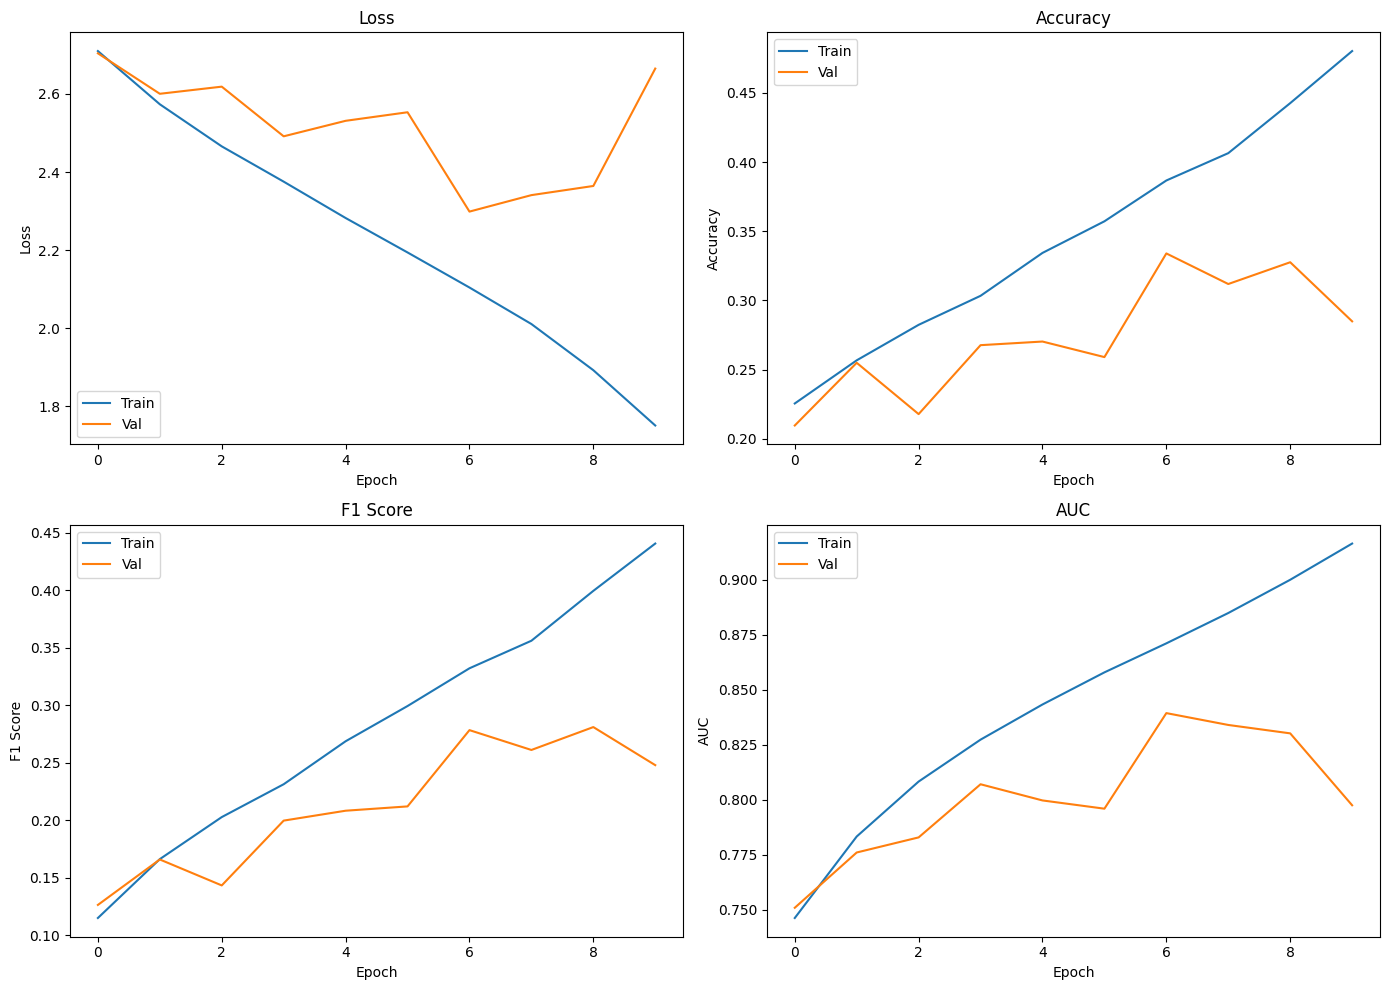

In [ ]:
plot_history(AD_first_model)

In [25]:
print("GPU disponível:", tf.test.is_gpu_available())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU disponível: False


# Pre-Trained Models

In [6]:
from keras.applications import ResNet50


O Primeiro modelo que vou testar é um ResNet 50, com dois dense layers, e tendo os weights dos modelos pre-trainded freaze

In [35]:
class my_ResNet50(Model):
    """
    Pre_trainned ResNet50

    """
    #Initialization
    def __init__(self):
        super().__init__(name="My_ResNet50")

        self.n_classes = 23
        self.Rescaling = Rescaling( scale= 1/127.5, offset=-1)
        self.base_model = ResNet50(include_top=False, weights="imagenet", classes=23)
        self.base_model.trainable = False  #Dar freaze ao modelo
        self.Flatten_layer = GlobalMaxPool2D()
        self.Dense_1 = Dense(120, activation="relu")
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)
        x = self.base_model(x, training = False) #Temos de ter training igual a false, mesmo tendo congelado o modelo emcima, porque                                    
        x = self.Flatten_layer(x)                                       #os batchnormalization layers continuam a treinar e neste primeiro teste não queremos isso
        x = self.Dense_1(x)
        x = self.Dense_2(x)

        return x


In [36]:
first_resnet50 = my_ResNet50()
inputs = Input(shape=input_shape)
_ = first_resnet50.call(inputs)
first_resnet50.summary()

Model: "My_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 120)            │       245,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 23)             │         2,783 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,836,375 (90.93 MB)

 Trainable params: 248,663 (971.34 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# inputs = Input(shape=input_shape)
# _ = model.call(inputs)
# model.summary()

In [22]:
epochs = 10
optimizer = SGD(learning_rate=0.001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")

In [23]:
#Dar complile do modelo
first_resnet50.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [25]:
first_resnet50_results= first_resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1166s 7s/step - accuracy: 0.1004 - auc: 0.5118 - f1_score: 0.0225 - loss: 3.1257 - val_accuracy: 0.1057 - val_auc: 0.5149 - val_f1_score: 0.0175 - val_loss: 3.1240
Epoch 2/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1151s 7s/step - accuracy: 0.1036 - auc: 0.5141 - f1_score: 0.0235 - loss: 3.1218 - val_accuracy: 0.0776 - val_auc: 0.5327 - val_f1_score: 0.0189 - val_loss: 3.1382
Epoch 3/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1150s 7s/step - accuracy: 0.1042 - auc: 0.5139 - f1_score: 0.0178 - loss: 3.1149 - val_accuracy: 0.1023 - val_auc: 0.5050 - val_f1_score: 0.0143 - val_loss: 3.1265
Epoch 4/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1150s 7s/step - accuracy: 0.1051 - auc: 0.5080 - f1_score: 0.0192 - loss: 3.1217 - val_accuracy: 0.1076 - val_auc: 0.5050 - val_f1_score: 0.0173 - val_loss: 3.1236
Epoch 5/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1150s 7s/step - accuracy: 0.1083 - auc: 0.5299 - f1_score: 0.0207 - loss: 3.1159 - val_accuracy: 0.1061 - val_auc: 0.5633 - val_f1_score: 0.0159

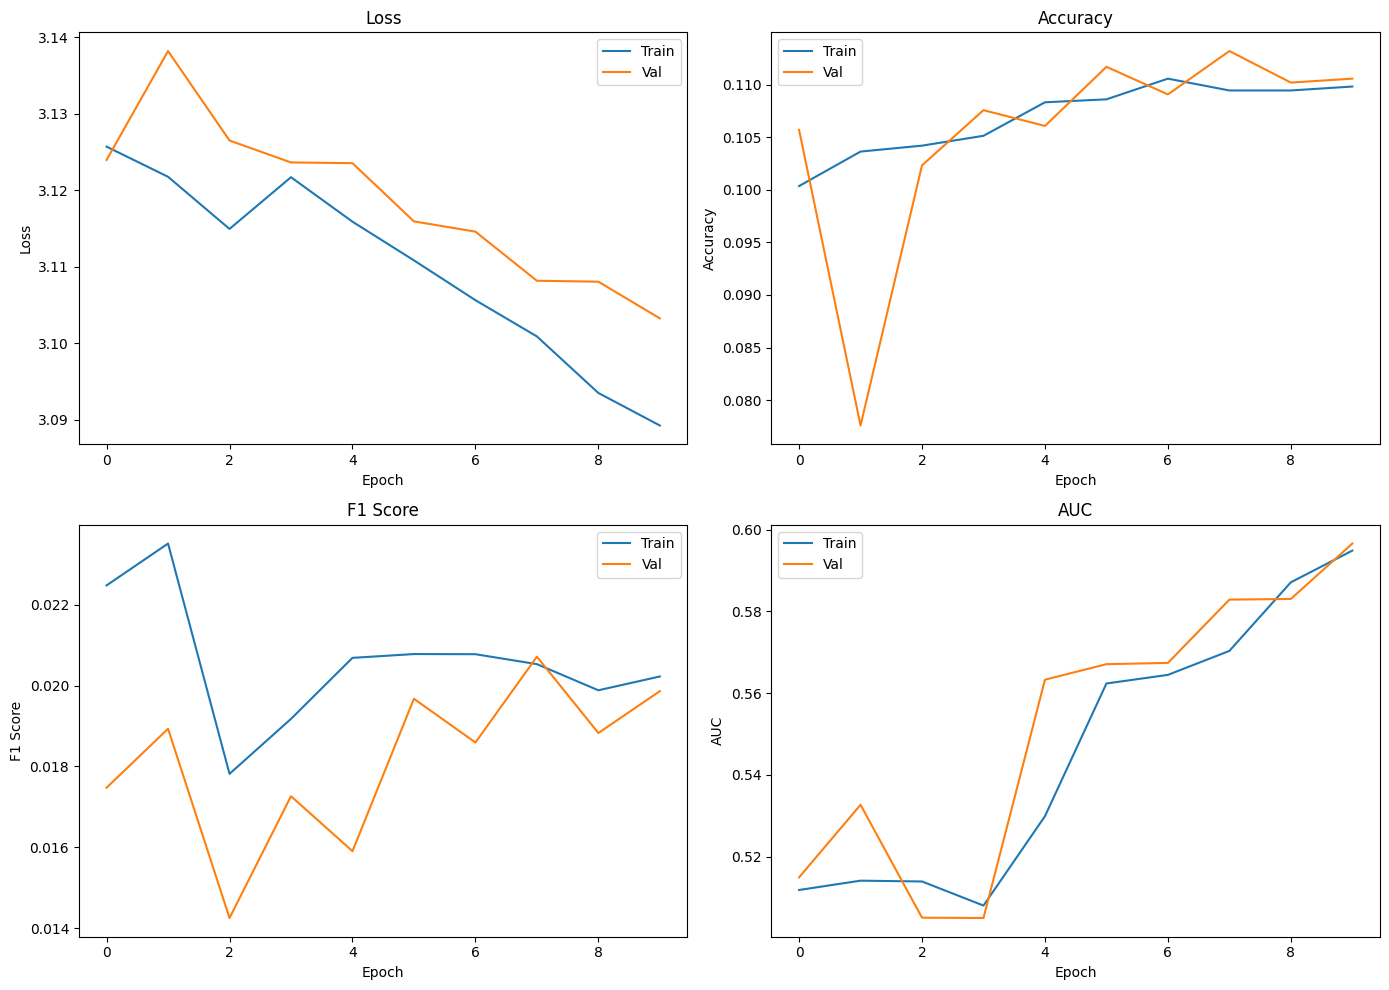

In [29]:
plot_history(first_resnet50_results)